<a href="https://colab.research.google.com/github/Pijon28/Pijon28/blob/main/Applied_Stats_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Using EigenDecomposition for sampling from MVN
- Given vector $\mu$ and matrix $\Sigma$ relevant to $\mathbb{R}^d$, we want to sample $n$ random points from the multivariate normal distribution described by mean $\mu$ and covariance matrix $\Sigma$
- We check if $\mu\in\mathbb{R}^d$ and whether $\Sigma$ is symmetric.
-   If not, then dump the procedure.
- If so, then we can perform spectral decomposition on symmetric $\Sigma$.
- We will have $\Sigma = USU^T$.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

A = np.array([
    [4.0, 1.2, 0.8, 0.5, 0.3, 0.2],
    [1.2, 3.5, 1.0, 0.4, 0.2, 0.1],
    [0.8, 1.0, 3.8, 0.6, 0.3, 0.2],
    [0.5, 0.4, 0.6, 2.9, 0.7, 0.3],
    [0.3, 0.2, 0.3, 0.7, 2.5, 0.6],
    [0.2, 0.1, 0.2, 0.3, 0.6, 2.2]
])

A = A[:3, :3]
muu = np.array([2.1, -1.3, 0.7, 3.4, -2.0, 1.5])
muu = muu[:3]

#Just initializaing a positive definite matrix A and random vector muu


### Scaling Down Covariance Matrices
To improve cluster separation, we will scale down the covariance matrices `A` and `cov` by a factor of 10.

In [ ]:
COV_SCALE_FACTOR = 0.5

### Global GMM Configuration
Centralizing the parameters for our mixture models to ensure consistency across sampling and clustering tasks.

In [ ]:
import numpy as np

# Centralized Parameters
# Use a subset of matrix A for consistent dimensionality (e.g., d=2)
DIM = 2
GMM_MEANS = [
    1.5*np.array([1, 1], dtype=float),   # m1
    np.array([-5, -2], dtype=float)  # m2
]

# Scaled covariance matrix derived from the initial matrix A
GMM_COVS = [
    (A[:DIM, :DIM]),
    (A[3-DIM:, 3-DIM:]*7)# / COV_SCALE_FACTOR
]

GMM_PROPORTIONS = [0.5, 0.5]
N_SAMPLES = 1000
choice_of_k = len(GMM_MEANS)

In [ ]:
print("=== GMM Parameters ===")
print(f"\nMeans:")
for i, mean in enumerate(GMM_MEANS):
    print(f"  μ{i+1} = {mean}")

print(f"\nCovariance Matrices:")
for i, cov in enumerate(GMM_COVS):
    print(f"  Σ{i+1} =\n{cov}\n")

print(f"Proportions: {GMM_PROPORTIONS}")
print(f"N Samples:   {N_SAMPLES}")
print(f"K:           {choice_of_k}")

=== GMM Parameters ===

Means:
  μ1 = [1.5 1.5]
  μ2 = [-5. -2.]

Covariance Matrices:
  Σ1 =
[[4.  1.2]
 [1.2 3.5]]

  Σ2 =
[[24.5  7. ]
 [ 7.  26.6]]

Proportions: [0.5, 0.5]
N Samples:   1000
K:           2


## Sampling from MVN(m, S)
- We know $X\sim MVN(\mu,\Sigma)$ implies $AX+b \sim MVN(A\mu+b,A^T\Sigma A)$, if A is full rank.
- If we take $A=U\Lambda^{-1/2}$, where $\Sigma = U\Lambda U^T$, then $A(X-\mu)\sim MVN(0, I)$.
- If $\Sigma$ is nonsingular, then this transformation is reversible.
- Therefore, we can sample from $X$ by applying the reverse transformation to a standard multivariate normal sample.
- In particular, if $Z\sim MVN(0,I)$, then $\Lambda^{1/2}U^TZ + \mu \sim MVN(\mu,\Sigma)$.

## Plan
- Accept $\mu\in\mathbb{R}^d, \Sigma\in\mathbb{M}_{d\times d}(\mathbb{R})$, and number of samples $n$. Verify whether they are appropriate mean and covariance matrices.
- Find SVD of $\Sigma$.
- Sample $n\times d$ times from $N(0,1)$ using python's libraries. Compile into $n$ many $d$-vectors.
- Apply the above described transformation to each vector, and return the "data matrix" thus formed.

In [ ]:
def numpy_eigh(A) :
  L, U = np.linalg.eigh(A)
  Ut = U.T
  return U,L,Ut

def mvn_sample(mu : np.ndarray,sigma : np.ndarray, n_samples : int) : # ASSUMES THE MATRIX IS POSITIVE SEMIDEFINITE. CANNOT ACCOUNT FOR NEGATIVE EIGENVALUES.
    mu_dim = mu.shape[0]
    sigma_cols = sigma.shape[1]
    norm_diff = np.linalg.norm(sigma.T - sigma)
    if not np.isclose(norm_diff, 0.0) :
        raise ValueError(f'Covariance matrix must be symmetric, norm of difference is {norm_diff}')
    if mu_dim != sigma_cols :
        raise ValueError(f'Dimension mismatch between mean {mu.shape} and covariance matrix {sigma.shape}')


    # If still here, then dimensions are okay. Can perform SVD.
    U,S,Ut = numpy_eigh(sigma) # S is a vector. Shapes are (d,d), (d,), (d,d).
    if S.min() <= 0.0 :
        raise ValueError(f'The covariance matrix not positive definite, eig_vals are {S}')


    # If still here, then MVN sampling is possible as per previously defined procedure.
    sqrt_S = np.diag(np.sqrt(S))




    def one_sample(X) : # Changes MVN(0_d, I_d) to MVN(mu, sigma)
        return U@sqrt_S@X + mu

    StdN_samples = np.random.normal(size=n_samples*mu_dim) # We want 10 samples of N(0_3,I_3) -> get 30 samples of N(0,1) and line them up into 10 3-vectors.

    DataMatrix = np.zeros((n_samples,mu_dim))

    for sample_number in range(n_samples):
        start = sample_number * mu_dim
        end = start + mu_dim
        # Now get the entries in bounds (start, end) into "a_sample"
        a_sample = np.array(StdN_samples[start:end], dtype=float)
        # Map a_sample through one_sample to get the correct (mu,sigma) configuration, and load it into the rows of an empty DataMatrix
        DataMatrix[sample_number] = one_sample(a_sample)

    return DataMatrix

## MVN sampling successful
- Below, we call the `mvn_sample` function on `muu` and `A`, which we defined early on, to produce 500 sample points.
- We calculate the sample mean and the sample covariance matrix to see how well we did.

In [ ]:
data = mvn_sample(mu=muu, sigma=A/COV_SCALE_FACTOR, n_samples=500)
# print(data)
sample_mean = data.mean(axis=0)
print(f"Sample mean is \n\n{sample_mean}\n\nOn the other hand, true mean was \n\n{muu}")
print()

sample_cov = np.cov(data.T)
print("Below is the sample covariance matrix : ")
print(sample_cov.round(3).astype(float))
print()

print("Below is the true covariance matrix (scaled) : ")
print((A/COV_SCALE_FACTOR).round(3).astype(float))
print("\n\nClearly, some coordinates are better approximated than others.")

Sample mean is 

[ 2.21222041 -1.14961063  0.92259973]

On the other hand, true mean was 

[ 2.1 -1.3  0.7]

Below is the sample covariance matrix : 
[[8.26  1.82  1.374]
 [1.82  6.515 2.159]
 [1.374 2.159 7.507]]

Below is the true covariance matrix (scaled) : 
[[8.  2.4 1.6]
 [2.4 7.  2. ]
 [1.6 2.  7.6]]


Clearly, some coordinates are better approximated than others.


## Sampling from a Mixture
- Now we will develop machinery to sample from a mixture of gaussians, with their own means and covariance matrices.
- We do not specify homoskedastic/heteroskedastic; the flexibility is built in.
- Problem :
  - We have not built in checks to match data dimensions, so the code can secretly fail due to input negligence.
### Plan
- Find a way to divide `n` samples (just their indices) into `k` parts, the relative proportion of each part should come from `p_1,p_2,...,p_k`. These are the mixture proportions.
- Sample `~ n*p_i` vectors from the `i`'th gaussian, and stack them all into one data matrix, then shuffle the rows.
- Bonus : return an additional column that contains the "true labels"!

In [ ]:
def mixture_sample(means : list[np.ndarray], covs : list[np.ndarray], proportions : list[float], n_samples : int):
  if len(means) != len(proportions):
      raise ValueError(f"Number of means ({len(means)}) and proportions ({len(proportions)}) don't match")
  if not np.isclose(sum(proportions), 1.0):
      raise ValueError("proportions must sum up to 1")
  sizes = [int(p*n_samples)+1 for p in proportions]
  k_centers = len(proportions)

  # List of arrays produced by gaussians :
  cluster_samples = [mvn_sample(mu = means[j], sigma = covs[j], n_samples = sizes[j]) for j in range(len(proportions))]
  cluster_samples = np.concatenate(cluster_samples, axis=0)

  L = [[i for j in range(sizes[i])] for i in range(k_centers)]
  true_labels = np.concatenate(L)

  # FIX: Shuffle both together using the same permutation
  rng = np.random.default_rng()
  indices = np.arange(len(cluster_samples))
  rng.shuffle(indices)

  cluster_samples = cluster_samples[indices]
  true_labels = true_labels[indices]

  # Drop extra samples
  cluster_samples = cluster_samples[:n_samples]
  true_labels = true_labels[:n_samples]
  return cluster_samples, true_labels

print("mixture_sample fixed! Run your sampling and clustering cells again to see the improved accuracy.")

mixture_sample fixed! Run your sampling and clustering cells again to see the improved accuracy.


## K Means
- Unsupervised learning technique.
- Plan :
  - Initialize (How?) `k` means.
  - Loop until iterations completed:
    - Assign each sample to the closest (Euclidean distance) `mean`;
    - Update the `means` to be the centroids of the classes thus made.
  - Return a matrix containing `means` as rows, and allocations. Allocations contain lists, each list (l_i) holds the ID's of the samples assigned to the corresponding (i'th) cluster.

### Ways to initialize
- We can pick `k` random entries from the data matrix, which guarantees no empty clusters
- We can pick on entry, then next one furthest from it, and so on. Lloyd's method.
- We can sample from `MVN(0,I)`. This is typically bad unless the data is centered.

In [ ]:
def sample_k_means_from_DataMatrix(k_means : int, DataMatrix : np.ndarray) :
  if k_means <= 0 :
    raise ValueError('k_means must be positive')
  n_samples, d_features = DataMatrix.shape
  if k_means > n_samples :
    raise ValueError('k_means must be less than or equal to the number of samples')
  # random_indices = np.random.randint(low=0, high=n_samples, size=k_means)

  random_indices = np.random.choice([indx for indx in range(n_samples)], size = k_means, replace=False)
  means = (DataMatrix[random_indices]).copy()
  return means # shape (k_means, d_features)


In [ ]:
def sample_k_means_by_spread(k_means : int, DataMatrix : np.ndarray):
  if k_means <= 0 :
    raise ValueError('k_means must be positive')

  n_samples, d_features = DataMatrix.shape

  # Initialise the means matrix
  means = np.zeros(shape=(k_means, d_features))

  #Choose first point randomly
  first_index = np.random.randint(low=0, high=n_samples)
  means[0] = (DataMatrix[first_index]).copy()

  #find the distances between the datapoints and the known centers
  for i in range(1, k_means) :
    dist = np.array([min([np.linalg.norm(sample - m)**2 for m in means[:i]]) for sample in DataMatrix])

    #Pick the datapoint with the maximum distance to its nearest center
    next_index = np.argmax(dist)
    means[i] = DataMatrix[next_index]
  return means # shape (k_means, d_features)

In [ ]:
def sample_k_means_by_mvn(k_means : int, DataMatrix : np.ndarray):
  if k_means <= 0 :
    raise ValueError('k_means must be positive')

  n_samples, d_features = DataMatrix.shape

  # This creates a k by d matrix where every number is picked from a Standard Normal distribution
  means = np.random.randn(k_means, d_features)
  return means # shape (k_means, d_features)

### Ways to initialize
- We have defined ways to initialize, now we add a consolidated option to choose the method. The user can just pass a string and the corresponding method is used.

In [ ]:
def k_means_init_method(method_to_initialize : str, k_means : int, DataMatrix : np.ndarray, manual_means=None):
  if method_to_initialize == 'datamatrix' :
    return sample_k_means_from_DataMatrix(k_means, DataMatrix)

  elif method_to_initialize == 'mvn' :
    return sample_k_means_by_mvn(k_means, DataMatrix)

  elif method_to_initialize == 'spread' :
    return sample_k_means_by_spread(k_means, DataMatrix)

  elif method_to_initialize == 'manual':
    if manual_means is None:
        raise ValueError("manual_means must be provided when init_method is 'manual'")
    return np.array(manual_means).copy()

  else :
    raise ValueError("Invalid method. The following are accepted as strings: `datamatrix`,`mvn`, `spread`, `manual`.")

In [ ]:
def k_means_algo(k_means : int, DataMatrix : np.ndarray, iters = 25, init_method = 'datamatrix', manual_means=None):
  n_samples, d_features = DataMatrix.shape
  if k_means > n_samples :
    raise ValueError('k_means must be less than or equal to the number of samples')
  means = k_means_init_method(method_to_initialize=init_method, k_means=k_means, DataMatrix=DataMatrix, manual_means=manual_means)

  current_iter = 0
  while current_iter < iters :
    list_of_assignments = [[] for i in range(k_means)]
    sample_id = 0

    while sample_id < n_samples :
      Distances_btw_us = [np.sum(np.square(DataMatrix[sample_id] - means[i])) for i in range(k_means)]
      allocation = Distances_btw_us.index(min(Distances_btw_us))
      list_of_assignments[allocation].append(sample_id)
      sample_id += 1

    for i in range(k_means) :
      if len(list_of_assignments[i]) > 0:
        means[i] = np.mean(DataMatrix[list_of_assignments[i]], axis=0)
    current_iter += 1
  return means, list_of_assignments

In [ ]:
def InClusterVars(means, list_of_assignments, datamatrix):
  Vars = []
  k = len(list_of_assignments)
  iterator = 0
  while iterator < k :
    my_mean = means[iterator]
    SSW = np.sum([np.sum(np.square(sample - my_mean)) for sample in datamatrix[list_of_assignments[iterator]]])
    Vars.append(float(SSW))
    iterator += 1
  return Vars

# Usage examples
- We present some toy examples of the usage of k-means algorithm.
- Afterwards, we adapt it to the latent cluster algorithm.

In [ ]:
# Using centralized parameters for sampling
DataMatrix, true_labels = mixture_sample(
    means=GMM_MEANS,
    covs=GMM_COVS,
    proportions=GMM_PROPORTIONS,
    n_samples=N_SAMPLES
)

### Standardizing Clustering Comparison
We can now run our different algorithms on the exact same dataset using the central `choice_of_k`.

In [ ]:
print("K-Means using Lloyd's method")
means, list_of_assignments = k_means_algo(k_means=choice_of_k, DataMatrix=DataMatrix, init_method='spread')
print("Calculated Means:\n", means)
print()
print("List of Assignments:\n", list_of_assignments)
print()
print("InClustervariances:\n", InClusterVars(means, list_of_assignments, DataMatrix))

K-Means using Lloyd's method
Calculated Means:
 [[ 0.93313587  1.54731577]
 [-7.52601841 -5.46735831]]

List of Assignments:
 [[1, 2, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 25, 28, 31, 32, 34, 37, 39, 41, 42, 43, 44, 45, 46, 49, 50, 52, 53, 55, 56, 57, 58, 59, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 84, 87, 88, 90, 91, 92, 94, 95, 96, 98, 101, 103, 104, 106, 110, 111, 112, 114, 116, 122, 123, 124, 125, 127, 133, 134, 135, 137, 139, 140, 141, 142, 145, 148, 149, 150, 152, 153, 154, 155, 156, 158, 159, 160, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 174, 175, 176, 179, 181, 183, 184, 186, 188, 189, 190, 191, 192, 193, 194, 196, 199, 200, 201, 202, 203, 204, 205, 206, 209, 211, 212, 213, 214, 217, 219, 220, 221, 223, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 237, 238, 240, 241, 242, 243, 244, 246, 248, 250, 251, 252, 253, 256, 257, 258, 259, 261, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 277,

In [ ]:
means, list_of_assignments = k_means_algo(k_means=choice_of_k, DataMatrix=DataMatrix, init_method='mvn')
print("Calculated Means:\n", means)
print()
print("List of Assignments:\n", list_of_assignments)
print()
print("InClustervariances:\n", InClusterVars(means, list_of_assignments, DataMatrix))

Calculated Means:
 [[-7.52601841 -5.46735831]
 [ 0.93313587  1.54731577]]

List of Assignments:
 [[0, 3, 4, 5, 11, 21, 24, 26, 27, 29, 30, 33, 35, 36, 38, 40, 47, 48, 51, 54, 60, 82, 83, 85, 86, 89, 93, 97, 99, 100, 102, 105, 107, 108, 109, 113, 115, 117, 118, 119, 120, 121, 126, 128, 129, 130, 131, 132, 136, 138, 143, 144, 146, 147, 151, 157, 161, 172, 173, 177, 178, 180, 182, 185, 187, 195, 197, 198, 207, 208, 210, 215, 216, 218, 222, 224, 235, 236, 239, 245, 247, 249, 254, 255, 260, 262, 270, 276, 278, 281, 282, 285, 287, 291, 292, 293, 295, 299, 304, 306, 311, 313, 315, 320, 327, 329, 331, 337, 338, 339, 342, 348, 350, 354, 355, 356, 364, 370, 372, 377, 384, 389, 392, 393, 394, 399, 400, 403, 415, 416, 421, 422, 424, 430, 432, 441, 442, 443, 444, 446, 447, 449, 450, 451, 452, 461, 462, 464, 471, 472, 474, 481, 484, 491, 492, 494, 495, 496, 502, 507, 511, 514, 515, 516, 523, 524, 526, 530, 532, 535, 536, 537, 539, 540, 543, 544, 545, 546, 549, 553, 558, 567, 568, 569, 571, 572, 574,

In [ ]:
means, list_of_assignments = k_means_algo(k_means=choice_of_k, DataMatrix=DataMatrix, init_method='datamatrix')
print("Calculated Means:\n", means)
print()
print("List of Assignments:\n", list_of_assignments)
print()
print("InClustervariances:\n", InClusterVars(means, list_of_assignments, DataMatrix))

Calculated Means:
 [[ 0.93313587  1.54731577]
 [-7.52601841 -5.46735831]]

List of Assignments:
 [[1, 2, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 25, 28, 31, 32, 34, 37, 39, 41, 42, 43, 44, 45, 46, 49, 50, 52, 53, 55, 56, 57, 58, 59, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 84, 87, 88, 90, 91, 92, 94, 95, 96, 98, 101, 103, 104, 106, 110, 111, 112, 114, 116, 122, 123, 124, 125, 127, 133, 134, 135, 137, 139, 140, 141, 142, 145, 148, 149, 150, 152, 153, 154, 155, 156, 158, 159, 160, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 174, 175, 176, 179, 181, 183, 184, 186, 188, 189, 190, 191, 192, 193, 194, 196, 199, 200, 201, 202, 203, 204, 205, 206, 209, 211, 212, 213, 214, 217, 219, 220, 221, 223, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 237, 238, 240, 241, 242, 243, 244, 246, 248, 250, 251, 252, 253, 256, 257, 258, 259, 261, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 277, 279, 280, 283, 284, 286, 288

### Plotting
- Below is some code that allows us to visualize the result of k-means. It plots the clusters onto the first two principal components.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Sampling from a Gaussian Mixture (Scaled)
- We use the scaling factor to ensure clusters are tight.

In [ ]:
print(DataMatrix)

[[-7.10010201 -2.69149709]
 [ 1.9463905  -2.40630441]
 [ 1.47785743 -2.95478927]
 ...
 [ 4.20521789  3.29709309]
 [-0.18104248 -3.49715719]
 [ 2.95170474  2.26623616]]


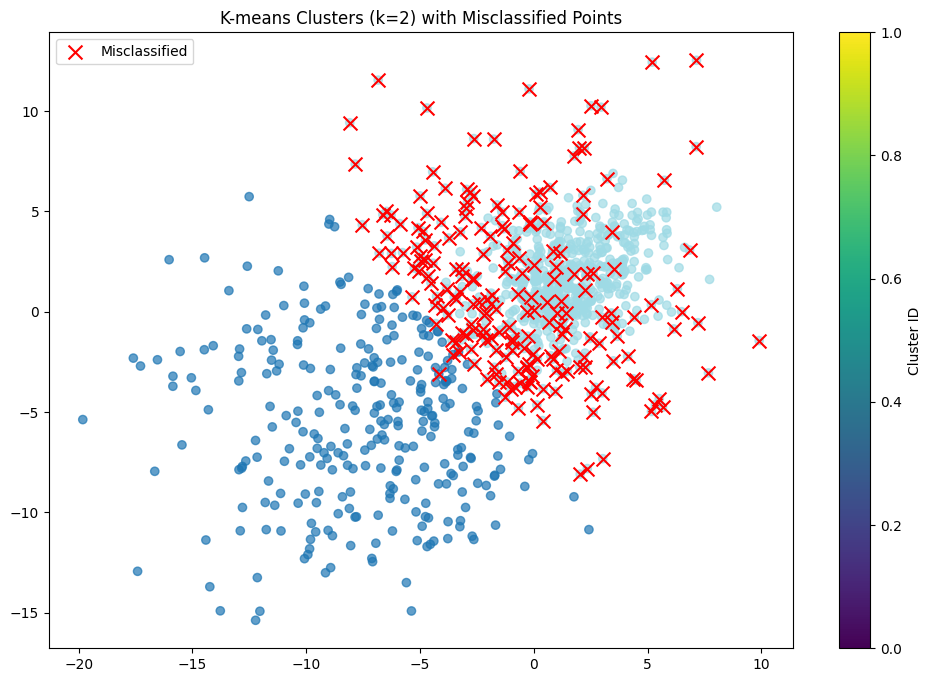

Accuracy: 78.90%


In [ ]:
# 1. Run k-means
choice_of_k = 2
means, list_of_assignments = k_means_algo(k_means=choice_of_k, DataMatrix=DataMatrix, init_method='datamatrix')

# 2. Extract k-means labels for every point
k_labels = np.zeros(DataMatrix.shape[0], dtype=int)
for cluster_id, point_indices in enumerate(list_of_assignments):
    for idx in point_indices:
        k_labels[idx] = cluster_id

# 3. Note: K-means labels might be swapped (e.g. true 0 is k-means 1)
# We can quickly align them by checking the majority class in each cluster
from scipy.stats import mode
aligned_labels = np.zeros_like(k_labels) # n-tuple
for i in range(choice_of_k):
    mask = (k_labels == i)
    if np.any(mask):
        actual_label = mode(true_labels[mask])[0]
        aligned_labels[mask] = actual_label

# 4. Visualize misclassifications
misclassified = (aligned_labels != true_labels)

# Data is 2D, no PCA needed
reduced = DataMatrix

plt.figure(figsize=(12, 8))

# Plot all points colored by k-means cluster
plt.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=k_labels,
    cmap='tab20',
    alpha=0.7
)

# Overlay misclassified points
plt.scatter(
    reduced[misclassified, 0],
    reduced[misclassified, 1],
    c='red',
    marker='x',
    s=100,
    label='Misclassified'
)

plt.title(f"K-means Clusters (k={choice_of_k}) with Misclassified Points")
plt.colorbar(label='Cluster ID')
plt.legend()
plt.show()

print(f"Accuracy: {100 * (1 - np.mean(misclassified)):.2f}%")

## Latent Cluster Analysis
- Accept the number of clusters to make, the datamatrix, the number of iterations, and the method to initialize a mean.
- Same algorithm as k-means, but at each step, we update the means, covariance matrices, and proportions to their corresponding MLE's
- Further, instead of distance, we compute the likelihood functions, and choose the cluster with maximum likelihood.
- First, a likelihood function for $MVN(\mu, \Sigma^2)$. Then adapted k-means.

In [ ]:
from scipy.stats import multivariate_normal as mvn
import numpy as np
def Z_j_func(mu_i : np.ndarray, cov_i : np.ndarray, x : np.ndarray) :
  i_likelihood_of_x = mvn.pdf(x, mean = mu_i, cov = cov_i, allow_singular=True)
  return i_likelihood_of_x

In [ ]:
def latent_cluster_hard(k_means: int, DataMatrix: np.ndarray, iters=25, init_method='datamatrix', reg=1e-4, manual_means=None):
    n_samples, d_features = DataMatrix.shape
    if k_means > n_samples:
        raise ValueError('k_means must be less than or equal to the number of samples')

    # Initialization
    means = k_means_init_method(method_to_initialize=init_method, k_means=k_means, DataMatrix=DataMatrix, manual_means=manual_means)
    cov_matrices = [np.identity(d_features) for _ in range(k_means)]
    proportions = np.array([1 / k_means for _ in range(k_means)])

    for _ in range(iters):
        # 1. HARD ASSIGNMENT STEP
        # Assign each sample to the most likely cluster based ONLY on the PDF (likelihood)
        list_of_assignments = [[] for _ in range(k_means)]

        # Compute likelihoods (PDF) for all points across all clusters
        all_likelihoods = np.zeros((n_samples, k_means))
        for k in range(k_means):
            # We use only the PDF here, not weighted by proportions
            all_likelihoods[:, k] = mvn.pdf(DataMatrix, mean=means[k], cov=cov_matrices[k], allow_singular=True)

        # Hard selection: Argmax over component likelihoods
        best_clusters = np.argmax(all_likelihoods, axis=1)

        for sample_id, cluster_id in enumerate(best_clusters):
            list_of_assignments[cluster_id].append(sample_id)

        # 2. UPDATE STEP (MLE based on hard assignments)
        for k in range(k_means):
            indices = list_of_assignments[k]
            N_k = len(indices)

            if N_k > 0:
                cluster_data = DataMatrix[indices]
                # Update Mean
                means[k] = np.mean(cluster_data, axis=0)

                # Update Covariance
                centered = cluster_data - means[k]
                cov_matrices[k] = (centered.T @ centered) / N_k + np.eye(d_features) * reg

                # Update Proportion based on assignment counts
                proportions[k] = N_k / n_samples
            else:
                # Handle Empty Clusters: Re-initialize from a random data point
                means[k] = DataMatrix[np.random.choice(n_samples)]
                cov_matrices[k] = np.identity(d_features)
                proportions[k] = 1 / n_samples

    # Final proportions normalization
    proportions = (proportions / proportions.sum()).tolist()

    return means, cov_matrices, proportions, list_of_assignments

In [ ]:
def latent_cluster(k_means : int, DataMatrix : np.ndarray, iters = 25, init_method = 'datamatrix', reg=1e-4, manual_means=None):
  n_samples, d_features = DataMatrix.shape
  if k_means > n_samples :
    raise ValueError('k_means must be less than or equal to the number of samples')

  # Initialization
  means = k_means_init_method(method_to_initialize=init_method, k_means=k_means, DataMatrix=DataMatrix, manual_means=manual_means)
  cov_matrices = [np.identity(d_features) for i in range(k_means)]
  proportions = np.array([1/k_means for i in range(k_means)])

  for _ in range(iters):
    # E-step
    # responsibilities[n, k] = p(z=k | x_n)
    responsibilities = np.zeros((n_samples, k_means))
    # this is the latent variable.

    for k in range(k_means):
      # Compute weighted likelihood for cluster k
      responsibilities[:, k] = proportions[k] * mvn.pdf(DataMatrix, mean=means[k], cov=cov_matrices[k], allow_singular=True)
    row_sums = responsibilities.sum(axis=1, keepdims=True)
    responsibilities = responsibilities / (row_sums + 1e-10) # Add epsilon to avoid division by zero
    # now for each sample point, we have responsibilities as a probability vector of length k_means.

    # M-STEP
    N_k = responsibilities.sum(axis=0) # Effective number of points in each cluster

    for k in range(k_means):
      if N_k[k] > 1e-5: # if cluster not supposed to be empty
        # Update Means
        means[k] = (responsibilities[:, k][:, np.newaxis] * DataMatrix).sum(axis=0) / N_k[k]

        # Update Covariances
        centered = DataMatrix - means[k]
        weighted_centered = responsibilities[:, k][:, np.newaxis] * centered
        cov_matrices[k] = (weighted_centered.T @ centered) / N_k[k] + np.eye(d_features) * reg

        # Update Proportions
        proportions[k] = N_k[k] / n_samples
      else:
        # Re-initialize cluster if it vanishes
        means[k] = DataMatrix[np.random.choice(n_samples)]
        cov_matrices[k] = np.identity(d_features)
        proportions[k] = 1/k_means

  # Final hard assignment for output consistency
  list_of_assignments = [[] for _ in range(k_means)]
  final_likelihoods = np.zeros((n_samples, k_means))
  for k in range(k_means):
    final_likelihoods[:, k] = proportions[k] * mvn.pdf(DataMatrix, mean=means[k], cov=cov_matrices[k], allow_singular=True)

  best_clusters = np.argmax(final_likelihoods, axis=1)
  for sample_id, cluster_id in enumerate(best_clusters):
    list_of_assignments[cluster_id].append(sample_id)

  return means, cov_matrices, proportions.tolist(), list_of_assignments

### Example usage
- Now we try out the latent cluster algorithm on our DataMatrix

In [ ]:
print(f"Running Latent Cluster Analysis on {N_SAMPLES} samples with K={choice_of_k}")
means_lc, covs_lc, props_lc, assignments_lc = latent_cluster(
    k_means=choice_of_k,
    DataMatrix=DataMatrix,
    init_method='datamatrix',
    iters=20
)

print("Recovered Proportions:", props_lc)
print("Recovered Means SSE:", [np.sum(np.square(means_lc[i] - GMM_MEANS[i])) for i in range(choice_of_k)])

Running Latent Cluster Analysis on 1000 samples with K=2
Recovered Proportions: [0.3834952067411656, 0.6165045486721626]
Recovered Means SSE: [np.float64(85.07106915744907), np.float64(51.277124944733806)]


In [ ]:
# DataMatrix = np.array([[1,1,1,1], [1.2,1,1,1], [3.5,3.5,3.5,4], [4,4,4,4], [6.5,7.2,29,100], [56,10,11,12], [3.14,15.9,2,1], [30,22,11,10.5]], dtype=float)
means, cov_matrices, proportions, list_of_assignments = latent_cluster(k_means=choice_of_k, DataMatrix=DataMatrix, init_method='spread')
print("Calculated Means:\n", means)
print()
print("List of Assignments:\n", list_of_assignments)
print()
print("Calculated Cov_matrices:\n", cov_matrices)
print()
print("Calculated Proportions:\n", proportions)
print()
print("InClusterVariances:\n", InClusterVars(means, list_of_assignments, DataMatrix))

Calculated Means:
 [[ 1.42621193  1.51396913]
 [-5.11403897 -2.94168341]]

List of Assignments:
 [[1, 2, 6, 7, 8, 9, 10, 12, 14, 15, 17, 19, 20, 22, 23, 25, 28, 31, 37, 39, 43, 44, 45, 46, 50, 52, 53, 55, 56, 57, 58, 59, 61, 62, 64, 65, 66, 67, 68, 70, 71, 72, 73, 74, 75, 76, 78, 79, 81, 84, 87, 88, 90, 91, 92, 94, 95, 98, 101, 103, 104, 106, 110, 111, 112, 116, 122, 124, 125, 133, 134, 135, 137, 139, 140, 145, 149, 152, 153, 154, 155, 156, 158, 159, 160, 162, 164, 166, 167, 168, 169, 170, 171, 174, 176, 183, 184, 186, 188, 190, 191, 192, 193, 194, 199, 200, 201, 202, 203, 204, 206, 209, 211, 212, 213, 214, 219, 220, 221, 223, 225, 226, 227, 228, 230, 232, 234, 237, 238, 240, 241, 242, 243, 244, 246, 248, 250, 251, 252, 253, 256, 257, 258, 259, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 277, 279, 280, 283, 284, 286, 288, 289, 290, 294, 296, 297, 300, 301, 303, 305, 307, 309, 310, 312, 316, 317, 318, 321, 322, 323, 324, 325, 328, 333, 334, 336, 340, 341, 343, 344, 345, 

In [ ]:
# DataMatrix = np.array([[1,1,1,1], [1.2,1,1,1], [3.5,3.5,3.5,4], [4,4,4,4], [6.5,7.2,29,100], [56,10,11,12], [3.14,15.9,2,1], [30,22,11,10.5]], dtype=float)
means, cov_matrices, proportions, list_of_assignments = latent_cluster(k_means=choice_of_k, DataMatrix=DataMatrix, init_method='mvn')
print("Calculated Means:\n", means)
print()
print("List of Assignments:\n", list_of_assignments)
print()
print("Calculated Cov_matrices:\n", cov_matrices)
print()
print("Calculated Proportions:\n", proportions)
print()
print("InClusterVariances:\n", InClusterVars(means, list_of_assignments, DataMatrix))

Calculated Means:
 [[ 1.49889536  1.55631634]
 [-4.6336243  -2.60719983]]

List of Assignments:
 [[1, 6, 7, 8, 9, 10, 12, 14, 15, 17, 19, 20, 22, 23, 25, 28, 31, 37, 39, 43, 44, 46, 50, 52, 53, 55, 56, 57, 59, 61, 62, 64, 65, 66, 67, 70, 71, 72, 73, 74, 75, 76, 78, 79, 81, 84, 87, 88, 90, 91, 92, 94, 95, 98, 101, 103, 104, 106, 110, 111, 112, 116, 122, 124, 125, 133, 134, 135, 137, 139, 145, 149, 152, 153, 154, 155, 156, 158, 159, 160, 162, 164, 166, 167, 168, 169, 170, 171, 174, 176, 183, 184, 188, 190, 191, 192, 193, 194, 199, 200, 201, 203, 204, 206, 209, 211, 212, 213, 214, 219, 220, 221, 223, 225, 226, 227, 228, 230, 232, 234, 237, 238, 240, 241, 242, 243, 246, 248, 250, 251, 253, 256, 257, 259, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 277, 279, 280, 283, 284, 286, 288, 289, 290, 294, 297, 300, 301, 303, 305, 307, 309, 310, 312, 316, 318, 321, 322, 323, 324, 325, 328, 333, 334, 336, 340, 341, 343, 344, 345, 346, 347, 351, 353, 357, 358, 359, 360, 361, 362, 366, 

In [ ]:
# DataMatrix = np.array([[1,1,1,1], [1.2,1,1,1], [3.5,3.5,3.5,4], [4,4,4,4], [6.5,7.2,29,100], [56,10,11,12], [3.14,15.9,2,1], [30,22,11,10.5]], dtype=float)
means, cov_matrices, proportions, list_of_assignments = latent_cluster(k_means=choice_of_k, DataMatrix=DataMatrix, init_method='datamatrix')
print("Calculated Means:\n", means)
print()
print("List of Assignments:\n", list_of_assignments)
print()
print("Calculated Cov_matrices:\n", cov_matrices)
print()
print("Calculated Proportions:\n", proportions)
print()
print("InClusterVariances:\n", InClusterVars(means, list_of_assignments, DataMatrix))

Calculated Means:
 [[-4.62451819 -2.60096541]
 [ 1.50018956  1.55714294]]

List of Assignments:
 [[0, 2, 3, 4, 5, 11, 13, 16, 18, 21, 24, 26, 27, 29, 30, 32, 33, 34, 35, 36, 38, 40, 41, 42, 45, 47, 48, 49, 51, 54, 58, 60, 63, 68, 69, 77, 80, 82, 83, 85, 86, 89, 93, 96, 97, 99, 100, 102, 105, 107, 108, 109, 113, 114, 115, 117, 118, 119, 120, 121, 123, 126, 127, 128, 129, 130, 131, 132, 136, 138, 140, 141, 142, 143, 144, 146, 147, 148, 150, 151, 157, 161, 163, 165, 172, 173, 175, 177, 178, 179, 180, 181, 182, 185, 186, 187, 189, 195, 196, 197, 198, 202, 205, 207, 208, 210, 215, 216, 217, 218, 222, 224, 229, 231, 233, 235, 236, 238, 239, 244, 245, 247, 249, 252, 254, 255, 258, 260, 261, 262, 270, 276, 278, 281, 282, 285, 287, 291, 292, 293, 295, 296, 298, 299, 302, 304, 306, 308, 311, 313, 314, 315, 317, 319, 320, 326, 327, 329, 330, 331, 332, 335, 337, 338, 339, 342, 348, 349, 350, 352, 354, 355, 356, 363, 364, 365, 368, 370, 372, 375, 376, 377, 384, 385, 388, 389, 390, 391, 392, 393, 39

### Plotting Latent Class Clustering
- Now we plot the latent class clustering to visualise its accuracy.

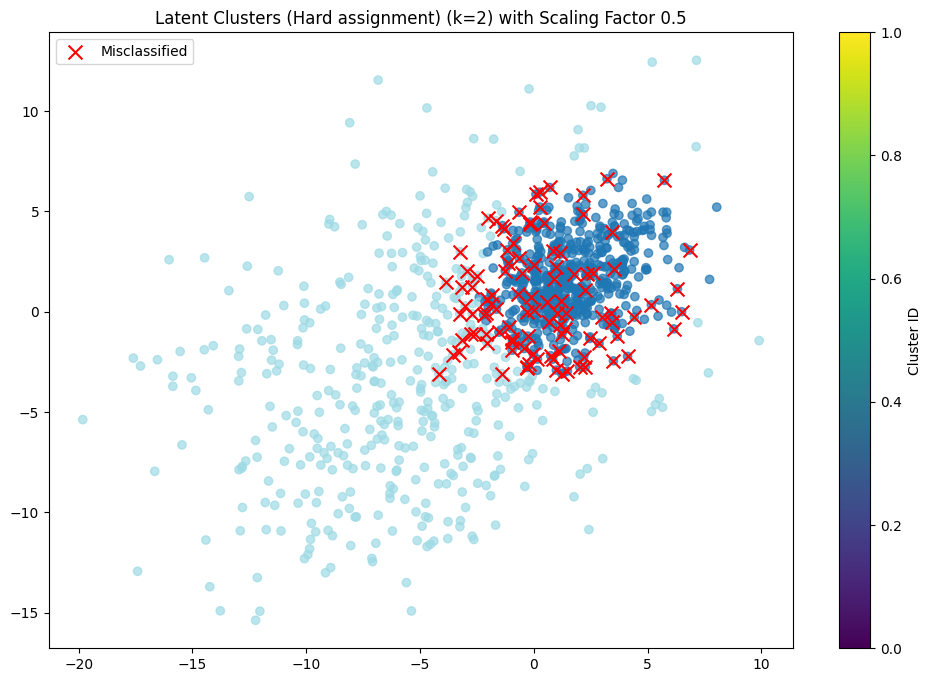

Accuracy: 89.60%


In [ ]:
# 1. Run LatentCluster
choice_of_k = 2
means_lc, cov_matrices, proportions, list_of_assignments = latent_cluster_hard(k_means=choice_of_k, DataMatrix=DataMatrix, init_method='datamatrix')

# 2. Extract k-means labels for every point
k_labels = np.zeros(DataMatrix.shape[0], dtype=int)
for cluster_id, point_indices in enumerate(list_of_assignments):
    for idx in point_indices:
        k_labels[idx] = cluster_id

# 3. Align labels
from scipy.stats import mode
aligned_labels = np.zeros_like(k_labels)
for i in range(choice_of_k):
    mask = (k_labels == i)
    if np.any(mask):
        actual_label = mode(true_labels[mask])[0]
        aligned_labels[mask] = actual_label

# 4. Visualize misclassifications
misclassified = (aligned_labels != true_labels)

# Data is 2D, no PCA needed
reduced = DataMatrix

plt.figure(figsize=(12, 8))
plt.scatter(reduced[:, 0], reduced[:, 1], c=k_labels, cmap='tab20', alpha=0.7)
plt.scatter(reduced[misclassified, 0], reduced[misclassified, 1], c='red', marker='x', s=100, label='Misclassified')
plt.title(f"Latent Clusters (Hard assignment) (k={choice_of_k}) with Scaling Factor {COV_SCALE_FACTOR}")
plt.colorbar(label='Cluster ID')
plt.legend()
plt.show()

print(f"Accuracy: {100 * (1 - np.mean(misclassified)):.2f}%")

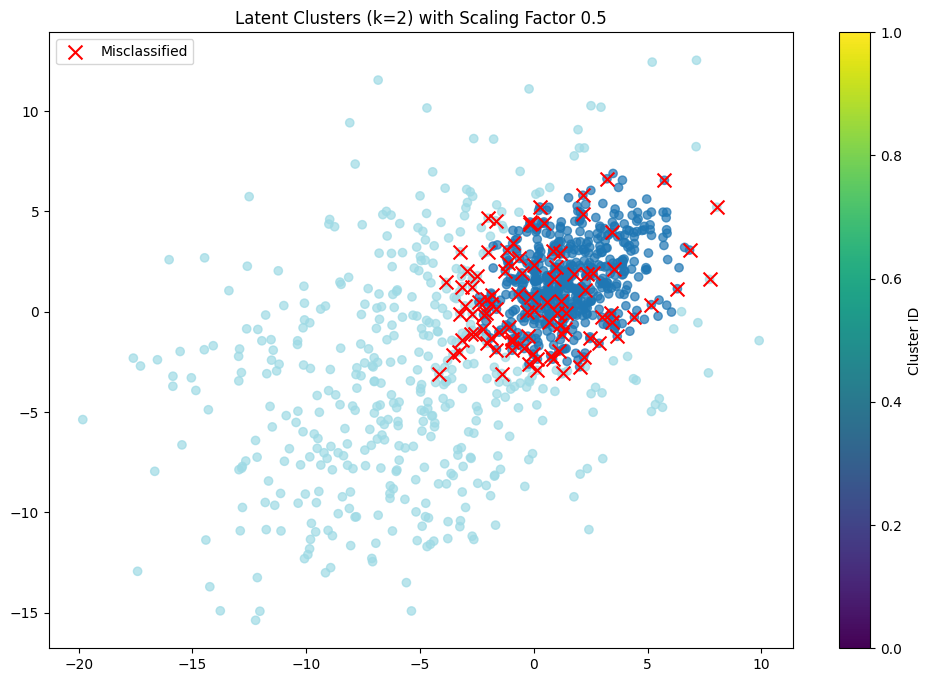

Accuracy: 90.40%


In [ ]:
# 1. Run LatentCluster
choice_of_k = 2
means_lc, cov_matrices, proportions, list_of_assignments = latent_cluster(k_means=choice_of_k, DataMatrix=DataMatrix, init_method='datamatrix')

# 2. Extract k-means labels for every point
k_labels = np.zeros(DataMatrix.shape[0], dtype=int)
for cluster_id, point_indices in enumerate(list_of_assignments):
    for idx in point_indices:
        k_labels[idx] = cluster_id

# 3. Align labels
from scipy.stats import mode
aligned_labels = np.zeros_like(k_labels)
for i in range(choice_of_k):
    mask = (k_labels == i)
    if np.any(mask):
        actual_label = mode(true_labels[mask])[0]
        aligned_labels[mask] = actual_label

# 4. Visualize misclassifications
misclassified = (aligned_labels != true_labels)

# Data is 2D, no PCA needed
reduced = DataMatrix

plt.figure(figsize=(12, 8))
plt.scatter(reduced[:, 0], reduced[:, 1], c=k_labels, cmap='tab20', alpha=0.7)
plt.scatter(reduced[misclassified, 0], reduced[misclassified, 1], c='red', marker='x', s=100, label='Misclassified')
plt.title(f"Latent Clusters (k={choice_of_k}) with Scaling Factor {COV_SCALE_FACTOR}")
plt.colorbar(label='Cluster ID')
plt.legend()
plt.show()

print(f"Accuracy: {100 * (1 - np.mean(misclassified)):.2f}%")

## Visualizing k-means against ground truth


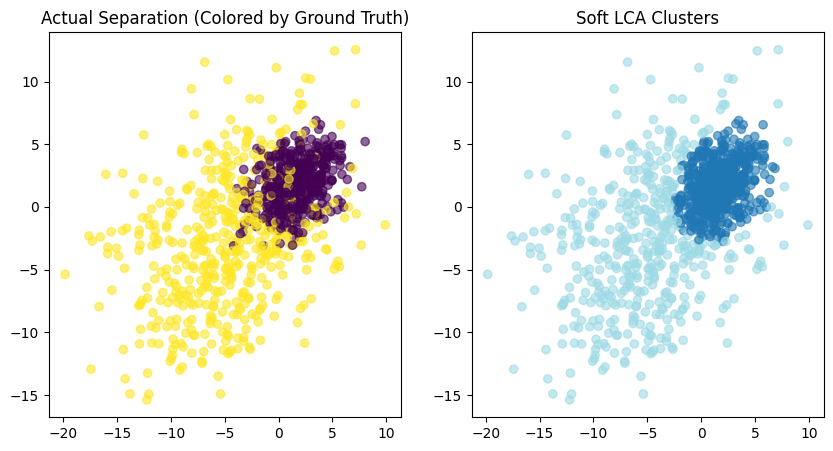

Distance from sample 0 to m1: 9.5672
Distance from sample 0 to m2: 2.2110
Ground truth label of sample 0: 1


In [ ]:
import matplotlib.pyplot as plt

# Let's check if the clusters are actually physically separated first
# If they are separated but accuracy is 50%, the issue is definitely label mapping

reduced_debug = DataMatrix # Data is 2D, no PCA needed

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(reduced_debug[:, 0], reduced_debug[:, 1], c=true_labels, cmap='viridis', alpha=0.6)
plt.title("Actual Separation (Colored by Ground Truth)")

plt.subplot(1, 2, 2)
plt.scatter(reduced_debug[:, 0], reduced_debug[:, 1], c=k_labels, cmap='tab20', alpha=0.6)
plt.title("Soft LCA Clusters")
plt.show()

# Diagnostic: Check the first few samples against means
print(f"Distance from sample 0 to m1: {np.linalg.norm(DataMatrix[0] - GMM_MEANS[0]):.4f}")
# Note: m2[::-1] was likely an attempt to align dimensions or check distance to a 'flipped' mean, which is not applicable anymore with explicit 2D means
# Assuming m2 is the correct comparison, not m2[::-1]
print(f"Distance from sample 0 to m2: {np.linalg.norm(DataMatrix[0] - GMM_MEANS[1]):.4f}")
print(f"Ground truth label of sample 0: {true_labels[0]}")

### Diagnostic Comparison: K-Means vs Latent Cluster
We will compare the recovered means and covariances from both algorithms against the ground truth `GMM_MEANS` and `GMM_COVS`.

In [ ]:
import pandas as pd

# Calculate SSE for Means
sse_km = [np.linalg.norm(means[i] - GMM_MEANS[i])**2 for i in range(choice_of_k)]
sse_lc = [np.linalg.norm(means_lc[i] - GMM_MEANS[i])**2 for i in range(choice_of_k)]

# Compare Proportions
print("--- Proportions ---")
print(f"True: {GMM_PROPORTIONS}")
print(f"LC Recovered: {props_lc}")

print("\n--- Means SSE (Lower is better) ---")
print(f"K-Means: {sse_km}")
print(f"Latent Cluster: {sse_lc}")

# Check Covariance recovery for Latent Cluster
print("\n--- Covariance Matrix Recovery (Latent Cluster Cluster 0) ---")
print("True Covariance (First 2x2):\n", GMM_COVS[0][:2, :2])
print("Recovered Covariance (First 2x2):\n", covs_lc[0][:2, :2])

# Logic Check: If LC SSE is much higher, the algorithm might be 'drifting'
# because of the covariance update step or label switching.

--- Proportions ---
True: [0.5, 0.5]
LC Recovered: [0.3834952067411656, 0.6165045486721626]

--- Means SSE (Lower is better) ---
K-Means: [np.float64(54.32764038447659), np.float64(54.90573014934017)]
Latent Cluster: [np.float64(0.002895222250904091), np.float64(0.5073258301337492)]

--- Covariance Matrix Recovery (Latent Cluster Cluster 0) ---
True Covariance (First 2x2):
 [[4.  1.2]
 [1.2 3.5]]
Recovered Covariance (First 2x2):
 [[20.88507761  5.31086028]
 [ 5.31086028 27.42719758]]


### Case Study: Non-Spherical Clusters
Here we create a dataset where the clusters are highly elliptical (different variances in different directions). K-Means will struggle because it tries to find circular partitions, whereas Latent Cluster should adapt to the elliptical shape.

In [ ]:
import numpy as np

# Create two highly elliptical clusters
mean_a = np.array([0, 0])
cov_a = np.array([[10, 8], [8, 10]]) # Elongated along y=x

mean_b = np.array([5, 0])
cov_b = np.array([[1, 0], [0, 1]])   # Small and circular

# Generate samples
pts_a = mvn_sample(mean_a, cov_a, 500)
pts_b = mvn_sample(mean_b, cov_b, 500)

# Combine into a new DataMatrix for this experiment
X_elliptical = np.concatenate([pts_a, pts_b])
Y_elliptical = np.concatenate([np.zeros(500), np.ones(500)])

# Shuffle
idx = np.random.permutation(len(X_elliptical))
X_elliptical, Y_elliptical = X_elliptical[idx], Y_elliptical[idx]

In [ ]:
print("--- Cluster A Parameters ---")
print(f"Mean A: {mean_a}")
print(f"Covariance A:\n{cov_a}")

print("\n--- Cluster B Parameters ---")
print(f"Mean B: {mean_b}")
print(f"Covariance B:\n{cov_b}")

--- Cluster A Parameters ---
Mean A: [0 0]
Covariance A:
[[10  8]
 [ 8 10]]

--- Cluster B Parameters ---
Mean B: [5 0]
Covariance B:
[[1 0]
 [0 1]]


In [ ]:
def compare_accuracy(DataMatrix, true_labels, k=2):
    # 1. K-Means
    m_km, a_km = k_means_algo(k, DataMatrix, init_method='datamatrix')
    labels_km = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_km): labels_km[ids] = cid

    # 2. Latent Cluster
    m_lc, c_lc, p_lc, a_lc = latent_cluster_hard(k, DataMatrix, init_method='datamatrix')
    labels_lc = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_lc): labels_lc[ids] = cid

    def get_acc(pred):
        from scipy.stats import mode
        aligned = np.zeros_like(pred)
        for i in range(k):
            mask = (pred == i)
            if np.any(mask): aligned[mask] = mode(true_labels[mask])[0]
        return np.mean(aligned == true_labels)

    print(f"K-Means Accuracy: {get_acc(labels_km)*100:.2f}%")
    print(f"Latent Cluster Accuracy: {get_acc(labels_lc)*100:.2f}%")

compare_accuracy(X_elliptical, Y_elliptical)

K-Means Accuracy: 80.70%
Latent Cluster Accuracy: 97.20%


In [ ]:
def compare_accuracy(DataMatrix, true_labels, k=2):
    # 1. K-Means
    m_km, a_km = k_means_algo(k, DataMatrix, init_method='spread')
    labels_km = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_km): labels_km[ids] = cid

    # 2. Latent Cluster
    m_lc, c_lc, p_lc, a_lc = latent_cluster_hard(k, DataMatrix, init_method='spread')
    labels_lc = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_lc): labels_lc[ids] = cid

    def get_acc(pred):
        from scipy.stats import mode
        aligned = np.zeros_like(pred)
        for i in range(k):
            mask = (pred == i)
            if np.any(mask): aligned[mask] = mode(true_labels[mask])[0]
        return np.mean(aligned == true_labels)

    print(f"K-Means Accuracy: {get_acc(labels_km)*100:.2f}%")
    print(f"Latent Cluster Accuracy: {get_acc(labels_lc)*100:.2f}%")

compare_accuracy(X_elliptical, Y_elliptical)

K-Means Accuracy: 80.70%
Latent Cluster Accuracy: 97.20%


In [ ]:
def compare_accuracy(DataMatrix, true_labels, k=2):
    # 1. K-Means
    m_km, a_km = k_means_algo(k, DataMatrix, init_method='mvn')
    labels_km = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_km): labels_km[ids] = cid

    # 2. Latent Cluster
    m_lc, c_lc, p_lc, a_lc = latent_cluster_hard(k, DataMatrix, init_method='mvn')
    labels_lc = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_lc): labels_lc[ids] = cid

    def get_acc(pred):
        from scipy.stats import mode
        aligned = np.zeros_like(pred)
        for i in range(k):
            mask = (pred == i)
            if np.any(mask): aligned[mask] = mode(true_labels[mask])[0]
        return np.mean(aligned == true_labels)

    print(f"K-Means Accuracy: {get_acc(labels_km)*100:.2f}%")
    print(f"Latent Cluster Accuracy: {get_acc(labels_lc)*100:.2f}%")

compare_accuracy(X_elliptical, Y_elliptical)

K-Means Accuracy: 80.80%
Latent Cluster Accuracy: 97.20%


In [ ]:
def compare_accuracy(DataMatrix, true_labels, k=2):
    # 1. K-Means
    m_km, a_km = k_means_algo(k, DataMatrix, init_method='mvn')
    labels_km = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_km): labels_km[ids] = cid

    # 2. Latent Cluster
    m_lc, c_lc, p_lc, a_lc = latent_cluster(k, DataMatrix, init_method='mvn')
    labels_lc = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_lc): labels_lc[ids] = cid

    def get_acc(pred):
        from scipy.stats import mode
        aligned = np.zeros_like(pred)
        for i in range(k):
            mask = (pred == i)
            if np.any(mask): aligned[mask] = mode(true_labels[mask])[0]
        return np.mean(aligned == true_labels)

    print(f"K-Means Accuracy: {get_acc(labels_km)*100:.2f}%")
    print(f"Latent Cluster Accuracy: {get_acc(labels_lc)*100:.2f}%")

compare_accuracy(X_elliptical, Y_elliptical)

K-Means Accuracy: 80.80%
Latent Cluster Accuracy: 97.30%


In [ ]:
def compare_accuracy(DataMatrix, true_labels, k=2):
    # 1. K-Means
    m_km, a_km = k_means_algo(k, DataMatrix, init_method='spread')
    labels_km = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_km): labels_km[ids] = cid

    # 2. Latent Cluster
    m_lc, c_lc, p_lc, a_lc = latent_cluster(k, DataMatrix, init_method='spread')
    labels_lc = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_lc): labels_lc[ids] = cid

    def get_acc(pred):
        from scipy.stats import mode
        aligned = np.zeros_like(pred)
        for i in range(k):
            mask = (pred == i)
            if np.any(mask): aligned[mask] = mode(true_labels[mask])[0]
        return np.mean(aligned == true_labels)

    print(f"K-Means Accuracy: {get_acc(labels_km)*100:.2f}%")
    print(f"Latent Cluster Accuracy: {get_acc(labels_lc)*100:.2f}%")

compare_accuracy(X_elliptical, Y_elliptical)

K-Means Accuracy: 80.70%
Latent Cluster Accuracy: 59.40%


In [ ]:
def compare_accuracy(DataMatrix, true_labels, k=2):
    # 1. K-Means
    m_km, a_km = k_means_algo(k, DataMatrix, init_method='datamatrix')
    labels_km = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_km): labels_km[ids] = cid

    # 2. Latent Cluster
    m_lc, c_lc, p_lc, a_lc = latent_cluster(k, DataMatrix)
    labels_lc = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_lc): labels_lc[ids] = cid

    def get_acc(pred):
        from scipy.stats import mode
        aligned = np.zeros_like(pred)
        for i in range(k):
            mask = (pred == i)
            if np.any(mask): aligned[mask] = mode(true_labels[mask])[0]
        return np.mean(aligned == true_labels)

    print(f"K-Means Accuracy: {get_acc(labels_km)*100:.2f}%")
    print(f"Latent Cluster Accuracy: {get_acc(labels_lc)*100:.2f}%")

compare_accuracy(X_elliptical, Y_elliptical)

K-Means Accuracy: 80.80%
Latent Cluster Accuracy: 97.30%


## Comprehensive Case Study Evaluation
This section centralizes the testing of all initialization methods across both clustering algorithms using our global GMM parameters.

In [ ]:
import numpy as np
from scipy.stats import mode

def get_aligned_accuracy(pred, true, k):
    aligned = np.zeros_like(pred)
    for i in range(k):
        mask = (pred == i)
        if np.any(mask):
            res = mode(true[mask], keepdims=True)
            aligned[mask] = res.mode[0]
    return np.mean(aligned == true)

n_trials = 10
km_accs = []
lc_accs = []

for _ in range(n_trials):
    # K-Means
    _, a_km = k_means_algo(choice_of_k, DataMatrix, init_method='datamatrix')#, iters=20)
    labels_km = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_km): labels_km[ids] = cid
    km_accs.append(get_aligned_accuracy(labels_km, true_labels, choice_of_k))

    # LCA
    _, _, _, a_lc = latent_cluster(choice_of_k, DataMatrix, init_method='datamatrix')#, iters=7)
    labels_lc = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_lc): labels_lc[ids] = cid
    lc_accs.append(get_aligned_accuracy(labels_lc, true_labels, choice_of_k))

print(f"K-Means Accuracy over {n_trials} runs: Mean={np.mean(km_accs):.4f}, Std={np.std(km_accs):.4f}")
print(f"LCA Accuracy over {n_trials} runs: Mean={np.mean(lc_accs):.4f}, Std={np.std(lc_accs):.4f}")


K-Means Accuracy over 10 runs: Mean=0.7890, Std=0.0000
LCA Accuracy over 10 runs: Mean=0.8895, Std=0.0362


### TESTING INITIALIZATION METHOD: datamatrix ###


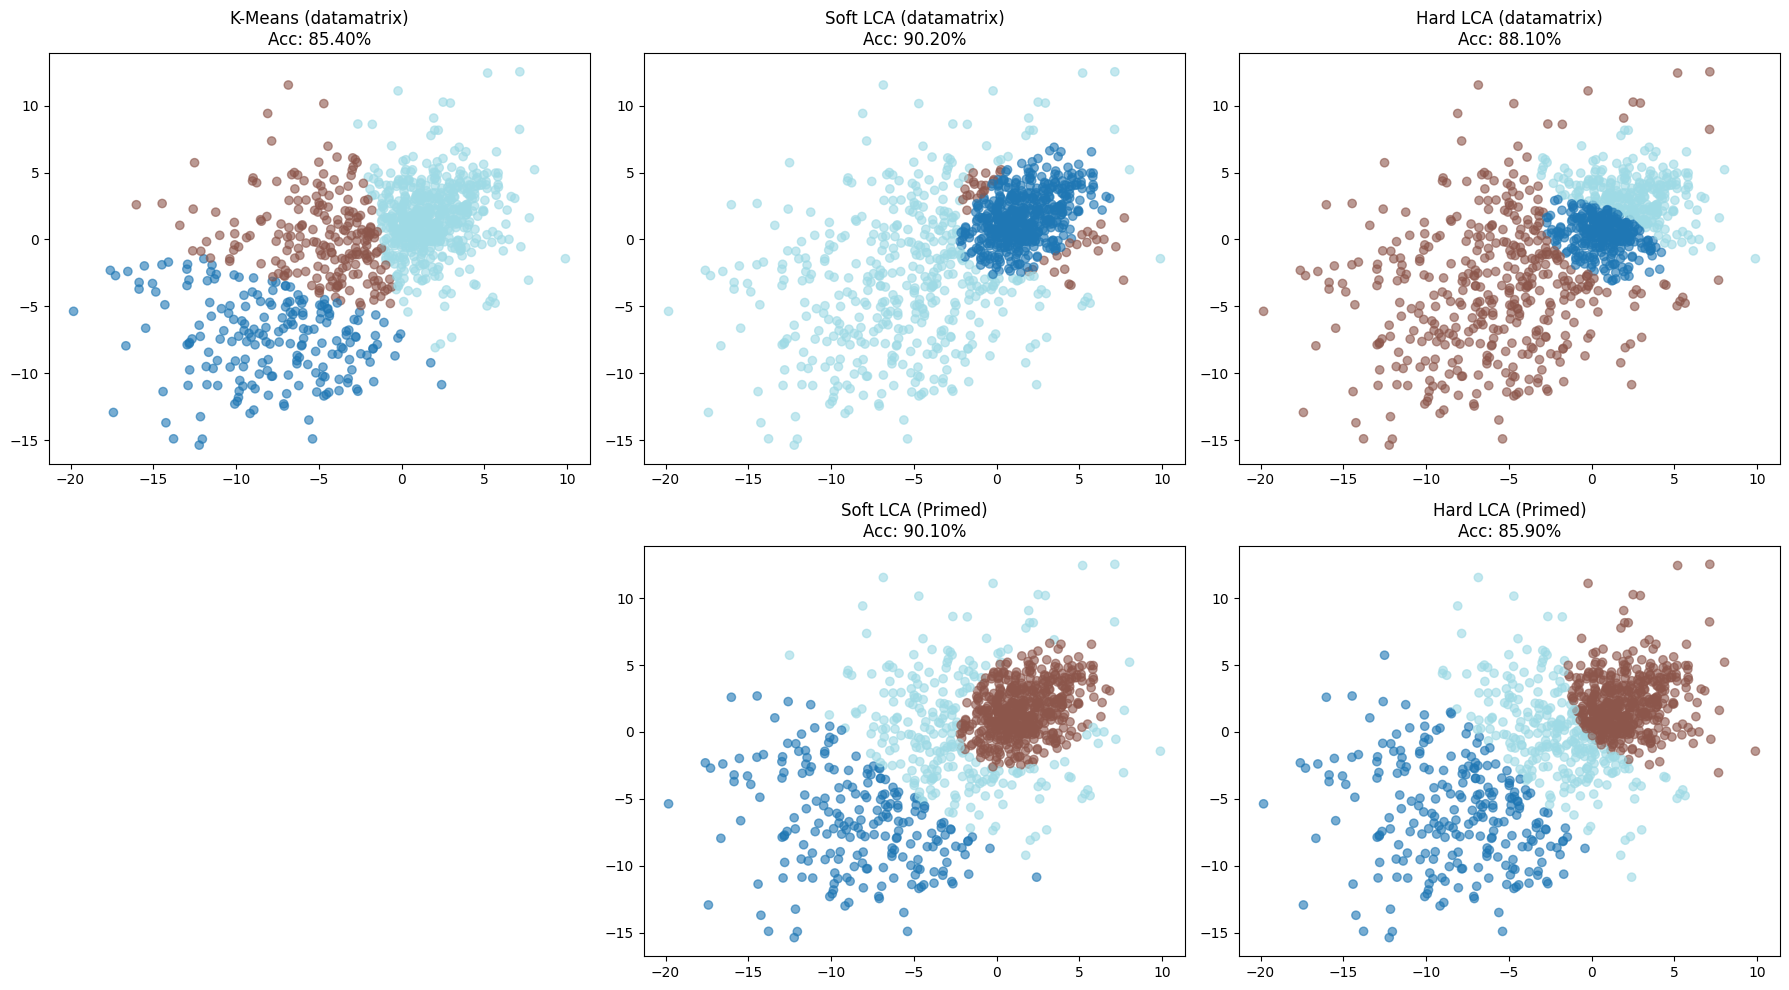

### TESTING INITIALIZATION METHOD: spread ###


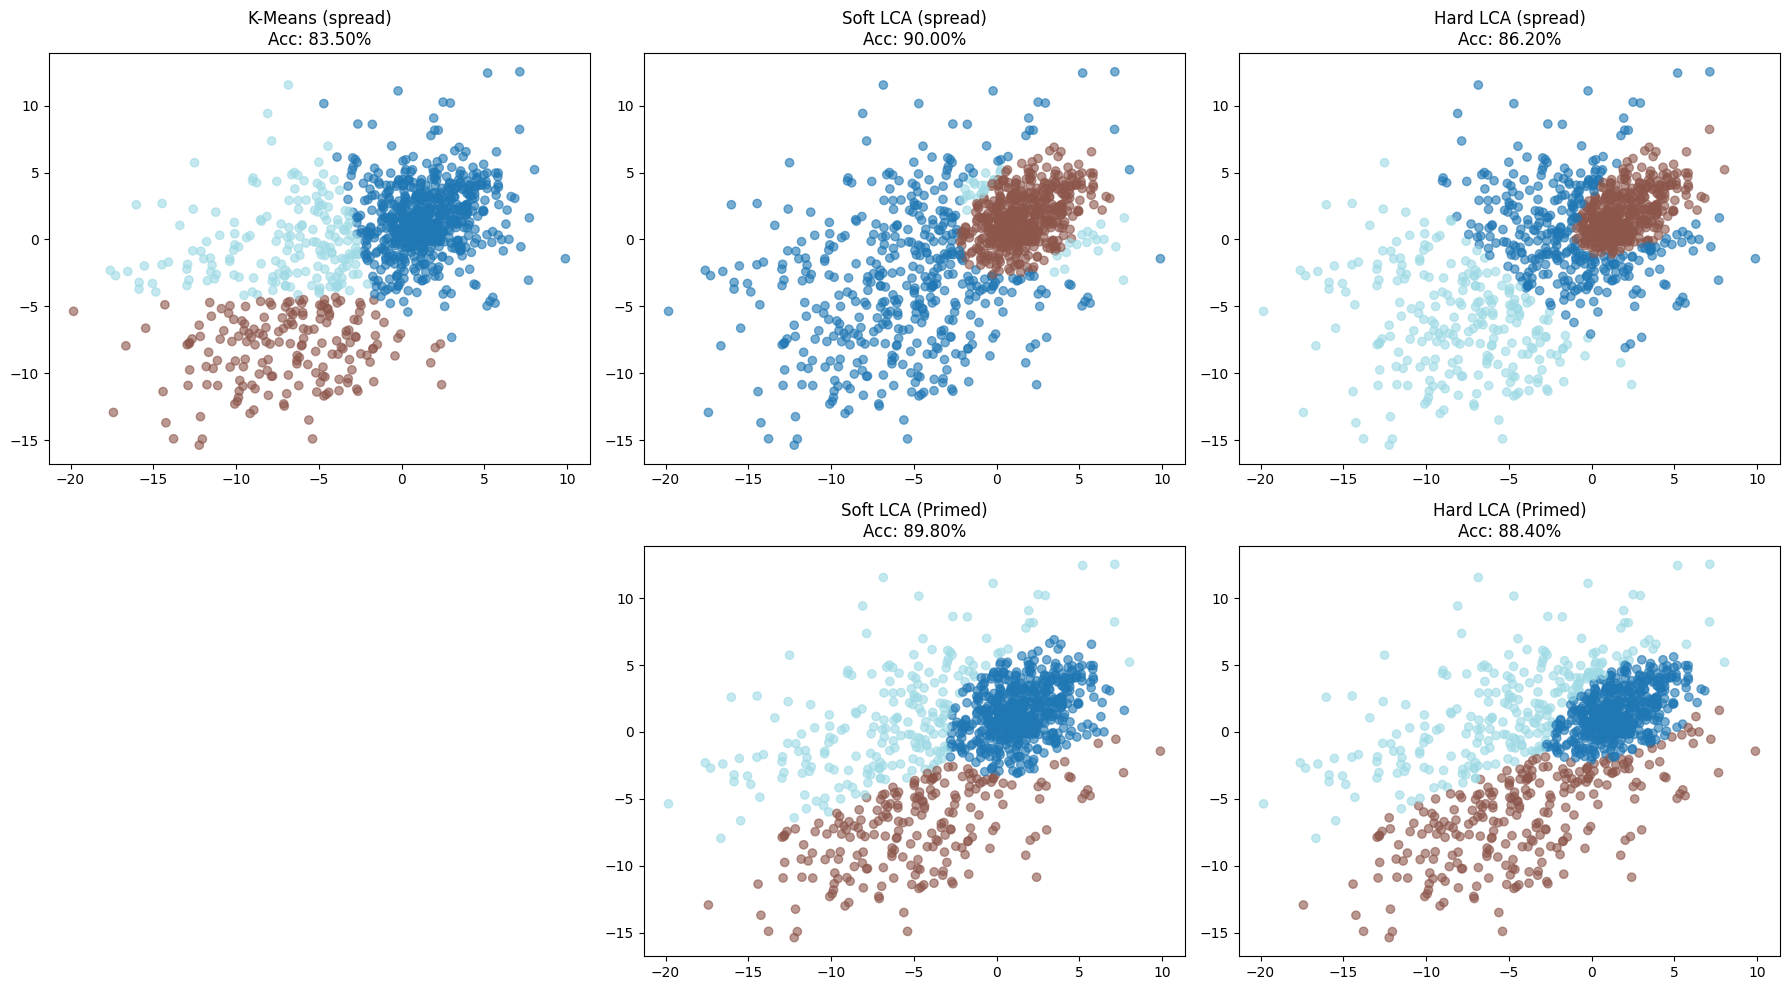

### TESTING INITIALIZATION METHOD: mvn ###


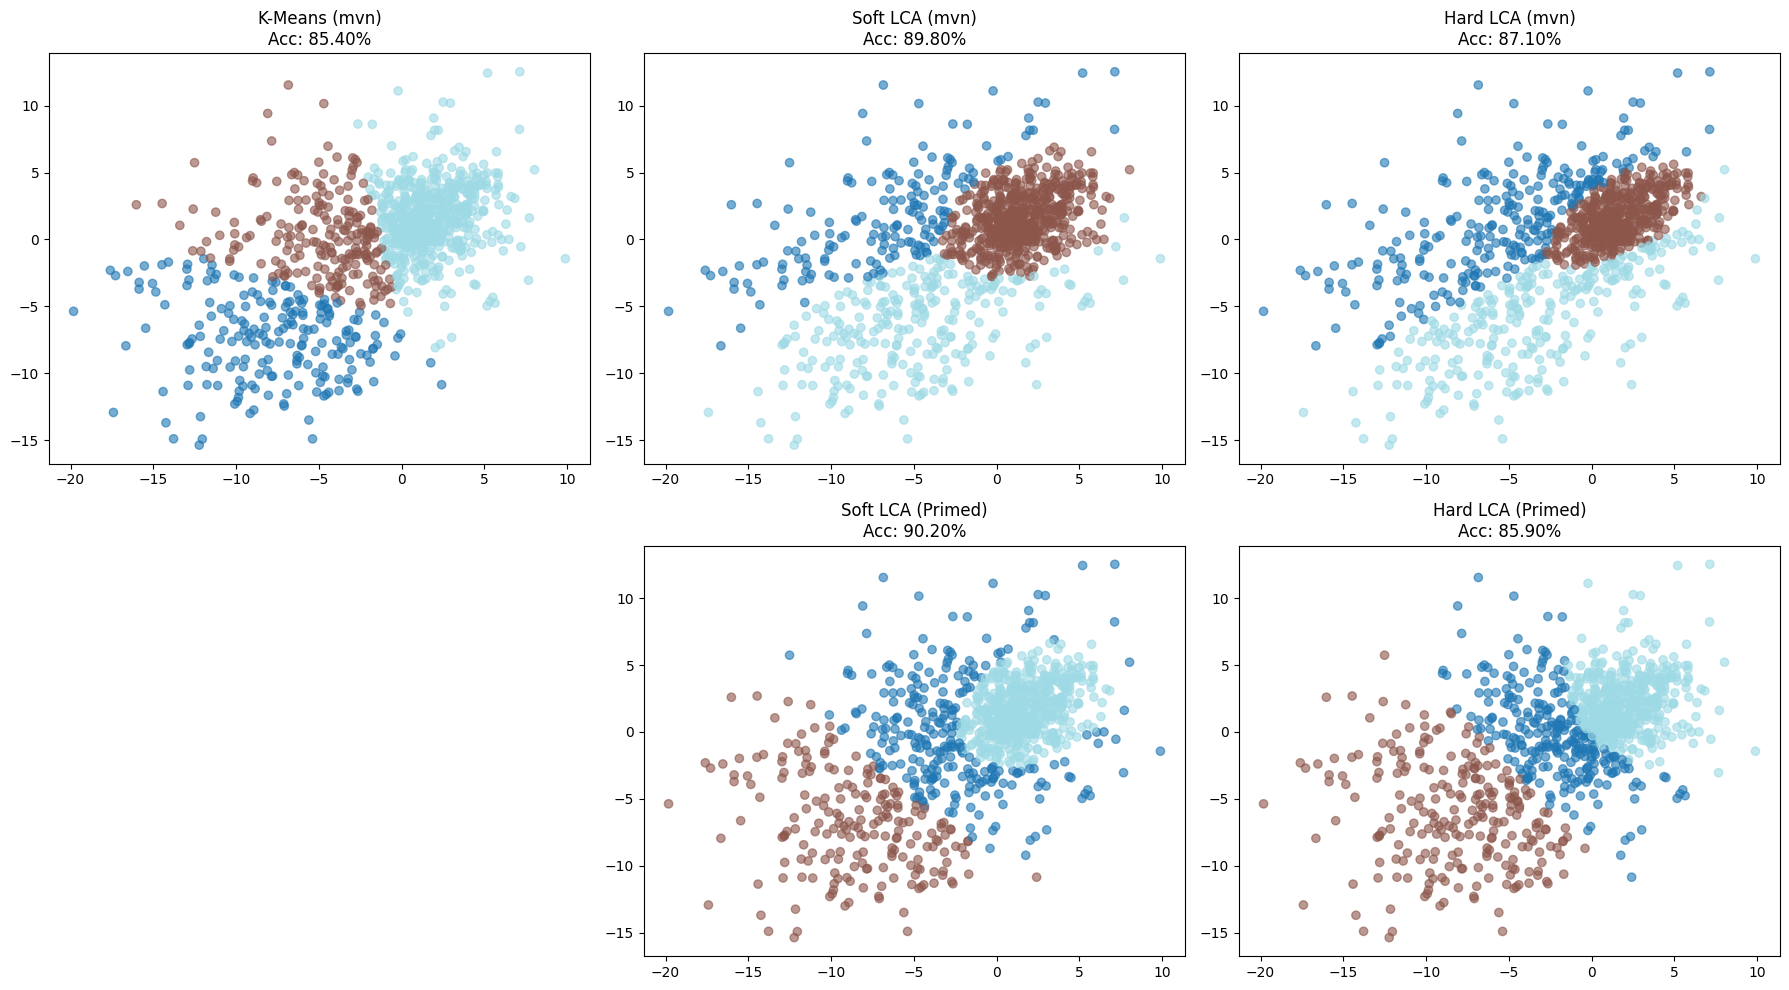

In [ ]:
INIT_METHODS = ['datamatrix', 'spread', 'mvn']
CHOICE_OF_K = 3
n_iters = 50

for method in INIT_METHODS:
    print(f"### TESTING INITIALIZATION METHOD: {method} ###")

    # 1. Run K-Means
    m_km, a_km = k_means_algo(CHOICE_OF_K, DataMatrix, init_method=method, iters=n_iters)
    labels_km = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_km): labels_km[ids] = cid

    # K-Means for priming (10 iterations)
    m_km_priming, _ = k_means_algo(CHOICE_OF_K, DataMatrix, init_method=method, iters=10)

    # 2. Run Soft LCA (Standard)
    m_soft, c_soft, p_soft, a_soft = latent_cluster(CHOICE_OF_K, DataMatrix, init_method=method, iters=n_iters)
    labels_soft = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_soft): labels_soft[ids] = cid

    # 3. Run Hard LCA (Standard)
    m_hard, c_hard, p_hard, a_hard = latent_cluster_hard(CHOICE_OF_K, DataMatrix, init_method=method, iters=n_iters)
    labels_hard = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_hard): labels_hard[ids] = cid

    # 4. Run Soft LCA (Primed by K-Means)
    m_soft_p, c_soft_p, p_soft_p, a_soft_p = latent_cluster(
        CHOICE_OF_K, DataMatrix, init_method='manual', manual_means=m_km_priming, iters=n_iters
    )
    labels_soft_p = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_soft_p): labels_soft_p[ids] = cid

    # 5. Run Hard LCA (Primed by K-Means)
    m_hard_p, c_hard_p, p_hard_p, a_hard_p = latent_cluster_hard(
        CHOICE_OF_K, DataMatrix, init_method='manual', manual_means=m_km_priming, iters=n_iters
    )
    labels_hard_p = np.zeros(len(DataMatrix))
    for cid, ids in enumerate(a_hard_p): labels_hard_p[ids] = cid

    # Visualization comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Row 1: Standard initialization
    axes[0,0].scatter(DataMatrix[:, 0], DataMatrix[:, 1], c=labels_km, cmap='tab20', alpha=0.6)
    axes[0,0].set_title(f"K-Means ({method})\nAcc: {get_aligned_accuracy(labels_km, true_labels, CHOICE_OF_K)*100:.2f}%")

    axes[0,1].scatter(DataMatrix[:, 0], DataMatrix[:, 1], c=labels_soft, cmap='tab20', alpha=0.6)
    axes[0,1].set_title(f"Soft LCA ({method})\nAcc: {get_aligned_accuracy(labels_soft, true_labels, CHOICE_OF_K)*100:.2f}%")

    axes[0,2].scatter(DataMatrix[:, 0], DataMatrix[:, 1], c=labels_hard, cmap='tab20', alpha=0.6)
    axes[0,2].set_title(f"Hard LCA ({method})\nAcc: {get_aligned_accuracy(labels_hard, true_labels, CHOICE_OF_K)*100:.2f}%")

    # Row 2: Primed versions
    axes[1,0].axis('off') # Placeholder/Reference is KM above

    axes[1,1].scatter(DataMatrix[:, 0], DataMatrix[:, 1], c=labels_soft_p, cmap='tab20', alpha=0.6)
    axes[1,1].set_title(f"Soft LCA (Primed)\nAcc: {get_aligned_accuracy(labels_soft_p, true_labels, CHOICE_OF_K)*100:.2f}%")

    axes[1,2].scatter(DataMatrix[:, 0], DataMatrix[:, 1], c=labels_hard_p, cmap='tab20', alpha=0.6)
    axes[1,2].set_title(f"Hard LCA (Primed)\nAcc: {get_aligned_accuracy(labels_hard_p, true_labels, CHOICE_OF_K)*100:.2f}%")

    plt.tight_layout()
    plt.show()
    print("="*80)